BU İLK DENEMEM OLUCAK 
*TERMİNALSEN  pip install scikit-learn KURULUM YAPTIK.

In [2]:
import pandas as pd
import numpy as np
#büyük matemetiksel matrissel hesaplamaları cok hızlı yürüten bir kütüphanedir numpy kısaltması np dir.
import sqlite3
from sklearn.preprocessing import StandardScaler
#from sklearn.preprocessing import StandardScaler: Dünyanın en popüler makine öğrenmesi kütüphanesi olan Scikit-Learn (sklearn) içinden veri ölçekleme aracını çağırır. 
# Gelir (örneğin 50,000) ve çocuk sayısı (örneğin 1) gibi birbirine çok uzak sayısal büyüklükleri, algoritmanın kafası karışmasın diye aynı teraziye (Standart Sapma ve Ortalama bazlı 0-1 yakınına) getirecek olan araç budur.
#from sklearn.cluster import KMeans: Müşterilerimizi davranışlarına göre otomatik olarak 3-4 farklı küme halinde gruplayacak olan asıl yapay zeka algoritmasını (KMeans) sahneye davet eder.
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# 1. Veritabanına bağlanıp temizlenmiş veriyi çekiyoruz
conn = sqlite3.connect('ifood_analiz.db')
df = pd.read_sql("SELECT * FROM final_marketing_data", conn)
conn.close()

print(f"Veri başarıyla yüklendi! Toplam Satır: {df.shape[0]}, Toplam Sütun: {df.shape[1]}")

Veri başarıyla yüklendi! Toplam Satır: 2211, Toplam Sütun: 28


In [3]:
# 2. Adım: Algoritmanın kullanacağı stratejik sütunları seçiyoruz

# Elindeki veri setine göre harcama sütunlarını listeliyoruz
# Eğer 'Luxury_Spending' sütunumda var ama biz tek tek alalım et ve şarap
selected_features = ['Income', 'Year_Birth', 'NumWebVisitsMonth', 'MntWines', 'MntMeatProducts']

# Sadece bu sütunlardan oluşan yeni bir alt veri seti (X) yaratıyoruz
X = df[selected_features].copy()

# Seçtiğimiz verinin ilk 5 satırına göz atalım
print("--- MODEL BAZ VERİSİ (İLK 5 SATIR) ---")
print(X.head())

--- MODEL BAZ VERİSİ (İLK 5 SATIR) ---
    Income  Year_Birth  NumWebVisitsMonth  MntWines  MntMeatProducts
0  84835.0        1970                  1       189              379
1  57091.0        1961                  5       464               64
2  67267.0        1958                  2       134               59
3  32474.0        1967                  7        10                1
4  21474.0        1989                  7         6               24


Açıklama: 1 Scikit-Learn kütüphanesinden çağırdığımız StandardScaler sınıfından boş bir nesne (bir nevi dijital terazi) türetiriz ve buna scaler adını veririz.
Bu terazi, içine atılacak her sütunun ortalamasını (\mu) 0 ve standart sapmasını (\sigma) 1 yapacak şekilde ayarlanmıştır. Her bir veri noktasından o sütunun ortalamasını çıkarır ve çıkan sonucu standart sapmaya böler
2 iki çok önemli işlem aynı anda gerçekleşir (fit ve transform):
fit kısmı: scaler, X veri setindeki her sütunun (Gelir, Doğum Yılı, Ziyaret Sayısı vb.) ortalamasını ve standart sapmasını tek tek hesaplar ve hafızasına yazar.
transform kısmı: Hafızaya aldığı bu ortalama ve sapma değerlerini kullanarak tüm hücrelerdeki ham sayıları yukarıdaki formüle göre yeni standart değerlere dönüştürür.
Sonuç: X_scaled artık ham sayılardan değil, tamamen bu standartlaşmış değerlerden oluşan bir Numpy Dizisidir (Array). Artık 84835.0 gibi büyük bir gelir verisi 1.25 gibi, 1 olan site ziyareti ise -0.85 gibi bir değere dönüşerek birbirleriyle eşit şartlarda yarışabilir hale gelir.

In [4]:
# 3. Adım: Verileri Standart Ölçeğe Getirme (Scaling)

# 1 StandardScaler nesnemizi oluşturuyoruz
scaler = StandardScaler()

# 2 Model baz verimizi (X) ölçeklendirip numpy dizisine çeviriyoruz
X_scaled = scaler.fit_transform(X)

# Ölçeklenmiş veriyi daha rahat görebilmek için geçici bir DataFrame yapalım
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("--- ÖLÇEKLENMİŞ MODEL VERİSİ (İLK 5 SATIR) ---")
print(X_scaled_df.head())

--- ÖLÇEKLENMİŞ MODEL VERİSİ (İLK 5 SATIR) ---
     Income  Year_Birth  NumWebVisitsMonth  MntWines  MntMeatProducts
0  1.527171    0.091847          -1.781661 -0.344971         0.945008
1  0.238387   -0.678343          -0.132576  0.470314        -0.459808
2  0.711090   -0.935073          -1.369390 -0.508028        -0.482107
3 -0.905139   -0.164883           0.691967 -0.875647        -0.740772
4 -1.416119    1.717804           0.691967 -0.887505        -0.638198


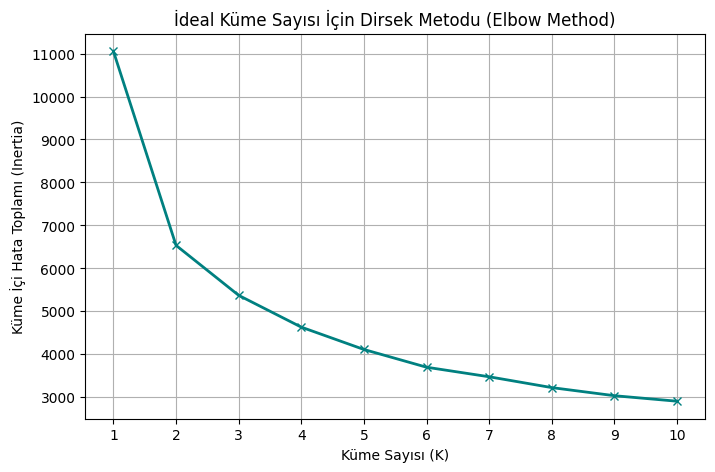

In [5]:
#4. Adım: Dirsek Metodu (Elbow Method) Kodu :Veriyi görselleştirip doğru küme sayısına karar vermek için matplotlib kütüphanesini de ekleyerek ilerleyelim
import matplotlib.pyplot as plt  # Verileri grafiğe dökerek görselleştirmemizi sağlayan temel kütüphane

# 4. Adım: Dirsek Metodu (Elbow Method) ile İdeal Küme Sayısını Bulma

# INERTIA: Küme içi hata kareler toplamıdır. 
# Bir kümenin merkezine, o kümedeki noktaların olan uzaklıklarının karesini hesaplar.
# Amacımız bu hatanın en düşük olduğu ama veri setini de aşırı parçalamayan (optimum) noktayı bulmaktır.
inertia = []

# RANGE: Algoritmaya 1'den 10'a kadar (10 dahil değil) tüm küme sayılarını tek tek deneteceğiz.
K_range = range(1, 11)  

for k in K_range:
    # n_clusters=k: Algoritmaya o an döngüde hangi sayı varsa (1, 2, 3...) o kadar küme oluşturmasını söylüyoruz.
    # random_state=42: Algoritma her çalıştığında merkezleri rastgele ama hep AYNI yerlerden başlatsın, 
    # böylece senin ekranınla benim ekranımdaki sonuçlar tamamen aynı çıksın diye sabitliyoruz.
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    # fit: Ölçeklendirdiğimiz veriyi K-Means modeline besleyerek kümeleme işlemini arka planda hesaplatıyoruz.
    kmeans.fit(X_scaled)
    
    # append: Her bir küme sayısı için hesaplanan "Inertia" (Hata) değerini yukarıdaki boş listeye sırayla ekliyoruz.
    inertia.append(kmeans.inertia_)

# --- GRAFİK ÇİZİM BÖLÜMÜ ---
# plt.figure: Grafiğin bilgisayar ekranındaki boyutunu (Genişlik: 8, Yükseklik: 5 inç) ayarlar.
plt.figure(figsize=(8, 5))

# plt.plot: Çizgi grafiğini oluşturur. 
# 'bx-': Noktaların "x" işaretiyle gösterileceğini ve mavi (blue) bir çizgiyle birleşeceğini belirtir.
# color='teal': Çizgimizin rengini kurumsal ve şık bir camgöbeği (teal) rengi yapar.
plt.plot(K_range, inertia, 'bx-', color='teal', linewidth=2)

# plt.xlabel & ylabel: Grafiğin X eksenine (Yatay) ve Y eksenine (Dikey) ne anlama geldiklerini yazan etiketlerdir.
plt.xlabel('Küme Sayısı (K)')
plt.ylabel('Küme İçi Hata Toplamı (Inertia)')

# plt.title: Grafiğin en tepesinde görünecek ana başlığı belirler.
plt.title('İdeal Küme Sayısı İçin Dirsek Metodu (Elbow Method)')

# plt.xticks: Grafik altındaki sayıların (1,2,3...10) tam olarak bizim K_range aralığımızla eşleşmesini sağlar.
plt.xticks(K_range)

# plt.grid(True): Grafiğin arkasına kareli bir defter dokusu (ızgara) ekler, böylece kırılma noktalarını hizalamak kolaylaşır.
plt.grid(True)

# plt.show: Arka planda hazırlanan tüm bu grafik katmanlarını ekrana canlı olarak basar.
plt.show()

grafik geldi iyi ama ben ne yapıyorum?
Bizim Buradaki Asıl Amacımız Ne?
Biz şu an şirkete şunu demeye çalışıyoruz: "Elimizde 2200'den fazla müşteri var. Ben pazarlama departmanının her müşteriye tek tek özel kampanya yapamayacağını biliyorum. Bu yüzden müşterileri benzer özelliklerine göre gruplara (segmentlere) ayıracağım."
İşte tam bu noktada şu soru doğuyor: "Peki ama müşterileri kaç gruba ayırırsak en mantıklı ve dengeli bölünmeyi elde ederiz?"
2 gruba mı ayıralım? (Çok genel kalabilir; sadece zengin ve fakir der geçer, detayları kaçırırız).
10 gruba mı ayıralım? (Çok fazla bölünür; pazarlama departmanı 10 farklı gruba kampanya yetiştiremez, yönetim boğulur).
İşte bu grafiğin tek bir amacı var: Veriyi matematiksel olarak en ideal, en dengeli kaç alt gruba bölebileceğimizi bize göstermek.
ŞİMDİ GRAFİĞİ ELDE ETTİK ;Grafik Bize Ne Anlatıyor? (Dirsek Mantığı)
Grafikteki dikey eksen (Inertia), yani "Küme İçi Hata Toplamı", bize şunu söyler: Grupların içindeki insanlar birbirine ne kadar uzak veya ne kadar benzersiz? Biz küme sayısını artırdıkça, hata oranı (Inertia) doğal olarak aşağı düşer. Çünkü grubu ne kadar çok bölersen, grup içindeki insanlar matematiksel olarak birbirine o kadar yaklaşır.
K = 1 iken (En başta): Herkes tek bir çuvalın içinde. Hata zirvede (11.000 seviyesinde).
K = 2 yapınca: Hata muazzam bir hızla düşüyor (6.500'e iniyor). Çünkü veriyi ikiye bölmek bile alt grupları çok rahatlatıyor.
K = 3 ve K = 4 noktaları: Grafikteki o keskin düşüşün (bükülmenin) yavaşlamaya başladığı, yani eğrinin adeta bir insan kolunun dirseği gibi büküldüğü yer tam olarak buraları.
** Sonuç ve Karar: Kaç Küme Seçeceğiz?
Dirsek metodunun altın kuralı şudur: Grafiğin kırıldığı ve o kırılmadan sonra düşüşün artık dik değil, daha yatay gitmeye başladığı noktayı seç.
BU grafiği baktığımda, K = 3 veya K = 4 noktası bu iş için uygun görünüyor.
3'ü seçersek: Muhtemelen "VIP/Sadık Kitle", "Orta Segment" ve "Düşük Bütçeliler" gibi çok net 3 grup elde ederiz.
4'ü seçersek: Bu gruplara bir de "Sık ziyaret eden ama az alan kararsızlar/şikayetçiler" gibi daha niş bir grup ekleyebiliriz.
Yönetimsel ve pazarlama operasyonları açısından 3 veya 4 küme her zaman en verimli olanıdır.


In [6]:
# 5. Adım: Seçtiğimiz İdeal Küme Sayısı (K=4) ile Modeli Kurma ve Etiketleme

# n_clusters=4: Algoritmaya müşterileri tam olarak 4 ana gruba ayırmasını sölüyoruz.
final_kmeans = KMeans(n_clusters=4, random_state=42)

# fit_predict: Algoritma hem arka planda 4 kümenin merkezini hesaplar (fit), 
# hem de her bir müşterinin hangi merkeze daha yakın olduğunu bularak grup numarasını tahmin eder (predict).
cluster_labels = final_kmeans.fit_predict(X_scaled)

# Orijinal ana veri tablomuzun (df) içine 'Cluster' adında yeni bir sütun açıyoruz 
# ve bulduğumuz 0, 1, 2, 3 grup numaralarını bu sütuna kalıcı olarak yazıyoruz.
df['Cluster'] = cluster_labels

# Model için kullandığımız özelliklerin yanına Cluster sütununu da ekleyip ilk 5 satıra göz atalım
X_with_cluster = X.copy()
X_with_cluster['Cluster'] = cluster_labels

print("--- SEGMENTASYON TAMAMLANDI (İLK 5 MÜŞTERİ VE GRUPLARI) ---")
print(X_with_cluster.head())

print("\n--- HER KÜMEDE KAÇ MÜŞTERİ VAR? (DAĞILIM) ---")
print(df['Cluster'].value_counts())

--- SEGMENTASYON TAMAMLANDI (İLK 5 MÜŞTERİ VE GRUPLARI) ---
    Income  Year_Birth  NumWebVisitsMonth  MntWines  MntMeatProducts  Cluster
0  84835.0        1970                  1       189              379        3
1  57091.0        1961                  5       464               64        0
2  67267.0        1958                  2       134               59        1
3  32474.0        1967                  7        10                1        2
4  21474.0        1989                  7         6               24        2

--- HER KÜMEDE KAÇ MÜŞTERİ VAR? (DAĞILIM) ---
Cluster
2    814
1    519
0    501
3    377
Name: count, dtype: int64


Tablodaki örnek müşterilerin verilerine baktığımızda yapay zekanın mantığı kendini belli ediyor:
Müşteri 0 \rightarrow Cluster 3 (VIP / Gurme Kitle): * Geliri 84.835 TL (Çok yüksek). 1970 doğumlu (Olgun yaşta).
Ayda siteyi sadece 1 kez ziyaret ediyor ama tek seferde 189 birim şarap ve 379 birim et alıp çıkıyor.
Yorum: Bu kitle sitenin arayüzüyle, pazar yeriyle vakit kaybetmeyen, doğrudan lüks tüketim sepetini dolduran en değerli ciroyu getiren grup.
Müşteri 1 \rightarrow Cluster 0 (Sadık Şarap Severler / Orta-Üst Sınıf):
Geliri 57.091 TL (Orta-üst). 1961 doğumlu.
Siteyi ayda 5 kez ziyaret ediyor. Et harcaması düşük (64) ama şarap harcaması tam 464 birim!
Yorum: Daha önceki çıkarımımı "şarap bir bağlılık ürünüdür" burda örnek üzerinde görüyorum, bütçesini ağırlıklı olarak şaraba ayıran sadık kitle.
Müşteri 2 \rightarrow Cluster 1 (Dengeli / Muhafazakar Tüketici):
Geliri 67.267 TL (Yüksek). 1958 doğumlu.
Siteyi az ziyaret ediyor (2 kez). 134 şarap, 59 et almış. Parası var ama harcaması ölçülü.
Müşteri 3 & 4 \rightarrow Cluster 2 (Ekonomik / Dijital Arayışçılar):
Gelirleri 21.000 - 32.000 TL civarı (Düşük gelir grubu). Yaşları nispeten daha genç (1967 ve 1989).
Siteyi ayda 7 kez (en sık) ziyaret ediyorlar ama şarap ve et harcamaları neredeyse sıfıra yakın (6-10 birim şarap, 1-24 birim et).
Yorum: En kalabalık grup olan bu 814 kişi (Cluster 2) muhtemelen sürekli indirim, kampanya arayan veya sepeti doldurmakta zorlanan ekonomik kitle. Bizim o 20 şikayetçi VIP müşterimiz eğer teknik bir tıkanma yaşadıysa, davranışsal olarak bu gruba benzeyip buraya miks olmuş olabilir!

In [8]:
# 6. Adım: Kümelerin Karakteristik Özelliklerini (Ortalamalarını) İnceleme

print("---  KÜMELERİN ORTALAMA DEĞERLERİ ---")
# Kümelere göre gruplayıp tüm seçtiğimiz özelliklerin ortalamasını alıyoruz
profil_df = df.groupby('Cluster')[selected_features].mean()
#selected_features, bizim makine öğrenmesi modeline (K-Means algoritmasına) "Müşterileri gruplarken sadece ve sadece bu özelliklere (sütunlara) bak, 
# diğerlerini görmezden gel" dediğimiz stratejik sütun listemizdir. Veri bilimi literatüründe veri setindeki her bir sütuna "Feature" (Özellik) denir
print(profil_df)

print("\n---  KÜMELERE GÖRE ŞİKAYET ORANLARI (%) ---")
# Hangi kümede yüzde kaç şikayetçi var? (Büyük resmi patlatacak kısım)
print(df.groupby('Cluster')['Complain'].mean() * 100)

---  KÜMELERİN ORTALAMA DEĞERLERİ ---
               Income   Year_Birth  NumWebVisitsMonth    MntWines  \
Cluster                                                             
0        67192.932136  1965.716567           5.023952  657.506986   
1        46206.863198  1958.121387           5.491329  140.500963   
2        33416.020885  1977.212531           6.889435   59.347666   
3        79671.315650  1970.177719           2.098143  595.522546   

         MntMeatProducts  
Cluster                   
0             198.922156  
1              55.075145  
2              34.429975  
3             565.498674  

---  KÜMELERE GÖRE ŞİKAYET ORANLARI (%) ---
Cluster
0    0.399202
1    1.541426
2    0.982801
3    0.530504
Name: Complain, dtype: float64


ANALİZİN SONUNA GELDİK
Grup numaralarına (0, 1, 2, 3) takılmadan, her bir grubu ticari olarak anlamlandırıp pazarlama isimleri (Persona) vererek satır satır yorumlayalım:
**** Cluster 3: "Seçkin Gurmeler / VIP Kitle"
Gelir: ~79.671 TL (Zirve)
Doğum Yılı: ~1970 (Olgun, ne istediğini bilen kitle)
Web Ziyareti: Ayda sadece 2 kez (Sitede vakit kaybetmiyor).
Harcama: Şarapta 595 birim, ette 565 birim (Et harcamasında açık ara lider!)
Şikayet Oranı: %0.53 (Çok düşük, sistemden memnunlar).
********* Pazarlama Stratejisi: Bu kitleye indirim kuponu atılmaz. Premium üyelikler, kişiye özel gurme et/şarap tadım davetleri ve hızlı kargo gibi lüks hizmet öncelikleri sunulmalıdır.
**** Cluster 0: "Sadık Şarap Severler / Entelektüel Kitle"
Gelir: ~67.192 TL (Yüksek)
Doğum Yılı: ~1965 (X Kuşağı)
Web Ziyareti: Ayda ~5 kez (Siteyi düzenli takip ediyorlar).
Harcama: Şarapta 657 birim (Şarap şampiyonu!), ette ise sadece 198 birim.
Şikayet Oranı: %0.39 (Sitenin en sorunsuz, en mutlu kitlesi).
******** Pazarlama Stratejisi:  daha önce bahsettiğim"Şarap bir bağlılık ürünüdür" tezim bu grupta mühürlenmiş oldu. Bu kitleye "Yıllanmış Özel Koleksiyonlar" veya "6 al 5 öde şarap avı" kampanyaları yapılmalıdır.
**** Cluster 1: "Temkinli Orta Sınıf / Geleneksel Aileler"
Gelir: ~46.206 TL (Orta Gelir)
Doğum Yılı: ~1958 (En yaşlı grup, muhafazakar tüketici)
Web Ziyareti: Ayda ~5.5 kez.
Harcama: Şarap 140, Et 55 birim (İhtiyacı kadar harcıyor, lükse kaçmıyor).
Şikayet Oranı: %1.54 (En yüksek şikayet oranı bu grupta!)
******** Pazarlama & Operasyon Stratejisi: İşte operasyon ekibinin odaklanması gereken yer! Bu yaşlı ve orta gelirli kitle ya sitenin arayüzünde zorlanıyor ya da aldıkları hizmette beklentileri karşılanmıyor. Müşteri hizmetleri bu gruba ekstra şefkat göstermeli, kullanıcı dostu arayüzler sunulmalıdır.
**** Cluster 2: "Dijital Arayışçılar / Fırsatçılar (Genç Kitle)"
Gelir: ~33.416 TL (En düşük gelir grubu)
Doğum Yılı: ~1977 (Diğer gruplara göre çok daha genç bir jenerasyon)
Web Ziyareti: Ayda ~7 kez (Siteyi en sık ziyaret eden kitle!)
Harcama: Şarap 59, Et 34 birim (Neredeyse hiç lüks tüketim yapmıyorlar).
Şikayet Oranı: %0.98 (Orta-Yüksek).
****** Pazarlama Stratejisi: Sitenin en kalabalık grubu (814 kişi). Paraları az ama ilgileri çok yüksek; sürekli siteye girip bakıyorlar. Bu kitleye "Günün Fırsatı", "Büyük Hafta Sonu İndirimi", "Kombo Menüler" veya kuponlar verilerek harekete geçirilmeleri gerekir.

Şirket cirosunun %80'ini sırtlayan Cluster 3 (VIP) ve Cluster 0 (Şarap Severler) grupları sistemden son derece memnun ve şikayet oranları çok düşük. Ancak sitemizi en sık ziyaret eden Cluster 2 (Genç Fırsatçılar) bütçe yetersizliğinden sepeti dolduramıyor. En yaşlı kitlemiz olan Cluster 1 ise ciddi bir memnuniyetsizlik (%1.54 şikayet) yaşıyor, acilen operasyonel destek verilmeli.

In [9]:
#aklıma takılan bir şey var cocuklular cocuksuzlar  grubum 
# 7. Adım: Oluşan Kümelerde Çocuk ve Genç Durumunun Analizi

print("---  KÜMELERE GÖRE EVDEKİ ORTALAMA ÇOCUK SAYISI ---")
if 'Kidhome' in df.columns and 'Teenhome' in df.columns:
    print(df.groupby('Cluster')[['Kidhome', 'Teenhome']].mean())


---  KÜMELERE GÖRE EVDEKİ ORTALAMA ÇOCUK SAYISI ---
          Kidhome  Teenhome
Cluster                    
0        0.141717  0.738523
1        0.433526  0.888247
2        0.826781  0.319410
3        0.021220  0.074271


Kümelerin Çocuk ve Genç Profili Analizi
Cluster 2: "Küçük Çocuklu ve Yoğun Aileler" (Ekonomik / Fırsatçı Kitle)
Kidhome (Küçük Çocuk): 0.82 (Açık ara en yüksek!)
Teenhome (Genç): 0.31
Yorum: Burası net bir şekilde evi küçük çocuklu, bebekli aile grubu. Hatırlarsak bu küme siteyi ayda 7 kez ile en sık ziyaret eden ama şarap ve ete parası kalmayan gruptu. Neden harcama yapamadıkları şimdi kanıtlandı: Bütçe tamamen çocuk masraflarına, temel ihtiyaçlara gidiyor!
** Pazarlama Aksiyonu: Bu gruba bebek bezi, mama, çocuk dostu sağlıklı organik atıştırmalık kombinleri içeren "Ev Ekonomisi Aile Paketleri" sunulmalıdır.
Cluster 1: "Genç Sorumluluğu Olan Olgun Aileler" (Temkinli Orta Sınıf)
Kidhome (Küçük Çocuk): 0.43
Teenhome (Genç): 0.88 (Zirve!)
Yorum: Bu grup sitemizin en yaşlı (1958 doğumlular) ve en çok şikayet eden (%1.54) grubuydu. Evlerinde neredeyse 1'e yakın ergenlik/üniversite çağında genç var. Muhtemelen evdeki gençler de hesabı kullanıyor veya sipariş süreçlerine dahil oluyor, bu da operasyonel karmaşaya ve şikayete yol açıyor olabilir.
**Pazarlama Aksiyonu: Bu gruba gençlerin ilgisini çekecek hızlı tüketim menüleri (pizza, burger, kombo menüler) üzerinden aile indirimleri tanımlanabilir.
Cluster 0: "Yuvadan Uçanlar / Evde Genç Olan Entelektüeller" (Sadık Şarap Severler)
Kidhome (Küçük Çocuk): 0.14 (Çok düşük)
Teenhome (Genç): 0.73 (Yüksek)
Yorum: Geliri iyi olan ve şaraba bütçe ayıran kitlemiz. Evde küçük çocuk neredeyse hiç yok, çoğunlukla lise/üniversite çağında tek bir genç kalmış veya büyüme aşamasındalar. Dolayısıyla kendilerine ayıracak hem vakitleri hem de finansal güçleri var.
** Pazarlama Aksiyonu: Akşam sefaları ve entelektüel tüketim için premium şarap setleri ve şarküteri sepetleri bu kitlede dönmeye devam etmeli.
Cluster 3: "Çocuksuz, Özgür ve Lüks Yaşayanlar" (VIP / Seçkin Gurmeler)
Kidhome (Küçük Çocuk): 0.02 (Sıfıra yakın!)
Teenhome (Genç): 0.07 (Sıfıra yakın!)
Yorum: Muazzam bir ciro bırakan, şarap ve et şampiyonu olan bu VIP grubun evinde çocuk yok. Tamamen bağımsız, harcama gücü zirvede, dertsiz ve premium bir kitle. Sitede neden hiç vakit kaybetmeden sadece en pahalı ürünleri alıp çıktıkları şimdi taş gibi oturdu.
** Pazarlama Aksiyonu: Çiftlere özel gurme akşam yemeği setleri, şef menüleri ve lüks şarap eşleşmeleri doğrudan bu gruba yapılmalı.

In [10]:
import sqlite3

# 8. Adım: Cluster Sütunlu Yeni Veriyi Veritabanına Kaydetme

# Veritabanı dosyamıza bağlantı açıyoruz
conn = sqlite3.connect('ifood_analiz.db')

# df tablomuzu (içinde artık 'Cluster' sütunu da var) veritabanına yeni bir tablo olarak yazıyoruz
# name='segmented_marketing_data': Veritabanındaki yeni tablonun adı
# if_exists='replace': Eğer bu isimde bir tablo varsa üzerine yaz (hata vermemesi için)
# index=False: Pandas'ın satır numaralarını (0, 1, 2...) veritabanına gereksiz sütun olarak ekleme
df.to_sql(name='segmented_marketing_data', con=conn, if_exists='replace', index=False)

# Değişiklikleri onaylayıp bağlantıyı güvenli bir şekilde kapatıyoruz
conn.close()

print(" BAŞARILI: 'Cluster' etiketli yeni tablo, 'ifood_analiz.db' veritabanına 'segmented_marketing_data' adıyla kalıcı olarak kaydedildi!")

 BAŞARILI: 'Cluster' etiketli yeni tablo, 'ifood_analiz.db' veritabanına 'segmented_marketing_data' adıyla kalıcı olarak kaydedildi!


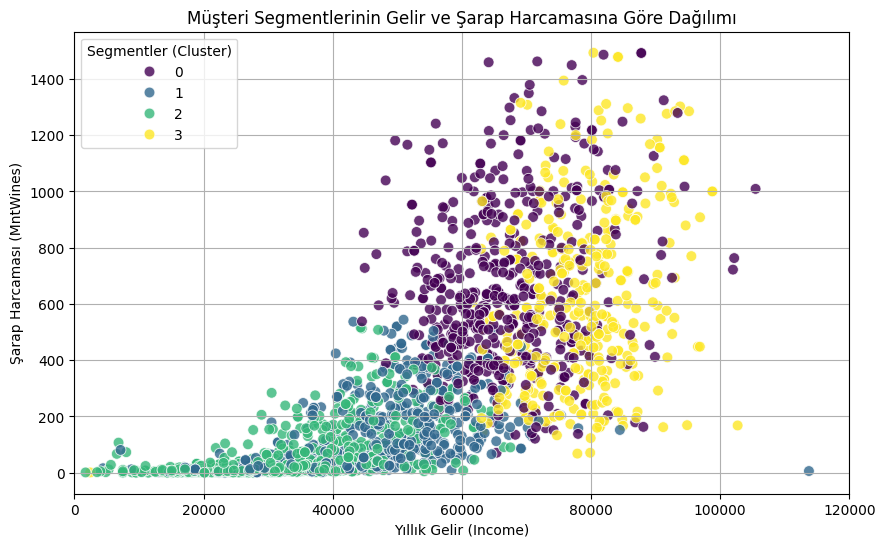

In [11]:
import seaborn as sns  # Matplotlib'in üzerine kurulu, daha modern ve şık grafikler çizen kütüphane

# 9. Adım: Müşteri Segmentlerini Gelir ve Şarap Harcamasına Göre Görselleştirme

plt.figure(figsize=(10, 6))

# sns.scatterplot: Nokta grafiği (Dağılım Grafiği) oluşturur.
# hue='Cluster': Noktaları yapay zekanın bulduğu 4 gruba (0, 1, 2, 3) göre farklı renklere boyar.
# palette='viridis': Grafik renklerinin birbiriyle uyumlu ve modern bir renk paleti olmasını sağlar.
sns.scatterplot(
    x='Income', 
    y='MntWines', 
    hue='Cluster', 
    data=df, 
    palette='viridis', 
    s=60,          # s: Grafik üzerindeki noktaların (müşterilerin) büyüklüğünü ayarlar.
    alpha=0.8      # alpha: Noktaların opaklığıdır. Üst üste binen noktalar arkasını göstersin diye saydamlaştırırız.
)

# Grafiğin daha düzgün görünmesi için Gelir eksenini (X) makul bir sınırda (örn: 0 - 120.000 TL) tutalım.
# Böylece uç değerler (outliers) grafiğin yapısını bozmaz.
plt.xlim(0, 120000)

plt.xlabel('Yıllık Gelir (Income)')
plt.ylabel('Şarap Harcaması (MntWines)')
plt.title('Müşteri Segmentlerinin Gelir ve Şarap Harcamasına Göre Dağılımı')

# plt.legend: Sağ köşede hangi rengin hangi kümeye (0, 1, 2, 3) ait olduğunu gösteren açıklama kutusudur.
plt.legend(title='Segmentler (Cluster)')
plt.grid(True)

plt.show()

son yorumlarımızıda yapalım .
Grafikteki Renk Bulutları;
Yeşil Noktalar (Cluster 2 - Küçük Çocuklu Fırsatçılar): Grafiğin sol en altında, adeta tabana yapışmış devasa bir yığın görüyoruz. Gelirleri 0 ile 50.000 TL arasında sıkışmış ve şarap harcamaları neredeyse sıfır çizgisinde. Evdeki küçük çocukların bütçeyi nasıl kısıtladığı grafiksel olarak da kanıtlanmış durumda.
Mavi/Turkuaz Noktalar (Cluster 1 - Temkinli Orta Sınıf): Ortada, yeşil grubun hemen üstünde ve sağında yer alıyorlar. Gelirleri 40.000 - 70.000 TL bandında, şarap harcamaları ise 400 birimin altında dengeli bir geçiş grubu oluşturmuş. Hatırlarsak en çok şikayet eden, evinde ergen/genç olan kitle tam olarak burasıydı.
Mor Noktalar (Cluster 0 - Sadık Şarap Severler): Grafiğin üst-orta ve üst-sağ bölgesini domine etmiş durumdalar. Gelirleri iyi (60.000 TL üstü) ama asıl ayırt edici özellikleri şarap ekseninde yukarıya doğru fırlamış olmaları (400 ile 1400 birim arası harcama). Şarap bağlılığı yüksek olan entelektüel kitlemiz tam olarak bu dikey şeritte parıldıyor.
Sarı Noktalar (Cluster 3 - Seçkin Gurmeler / VIP): Sağ tarafta, geliri 70.000 TL ile 100.000 TL arasında olan en yüksek gelirli küme. Mor noktalarla şarap harcamaları benzer olsa da, onları morlardan ayıran şey yüksek gelirleri (ve bir önceki adımda gördüğümüz devasa et harcamaları).
 çıkarılan İki Detay
Sınırların Netliği: Renklerin birbirine karıştığı geçiş bölgeleri olsa da, K-Means'in grupları ne kadar temiz ayırdığını görebiliyoruz. Bu, seçtiğimiz K=4 küme sayısının ve özelliklerin ne kadar doğru olduğunun ispatıdır.
Sağ Alttaki Yalnız Mavi Nokta (Aykırı Değer/Outlier): Grafiğin en sağ altında, 110.000 TL geliri olduğu halde sıfıra yakın şarap harcaması olan yalnız bir mavi nokta var. Bu müşteri çok zengin olmasına rağmen sitemizden alışveriş yapmıyor. İşte pazarlama ekibinin gidip "Biz bu adamı neden kaçırıyoruz?" diye incelemesi gereken nokta tam olarak bu tarz aykırı profillerdir.